### Sección 1: Limpieza y Reducción del Dataset

En esta sección se ejecuta el preprocesamiento de los datos crudos. El objetivo es transformar el dataset original (orientado a jugadores) en un dataset agregado y simplificado (orientado a equipos), garantizando la integridad de la información para el análisis estadístico posterior.

El procedimiento abarca las siguientes etapas:
* **Filtrado de Integridad:** Se seleccionan exclusivamente las partidas en modo "CLASSIC" con una duración superior a 10 minutos (600 segundos), descartando registros irrelevantes o corruptos.
* **Estandarización de Variables:** Se normaliza la variable objetivo `win` a un formato binario numérico ($1$ para victoria, $0$ para derrota), unificando los diversos formatos presentes en la fuente original.
* **Validación Estructural:** Se verifica que cada equipo esté compuesto por exactamente 5 integrantes. Los registros que no cumplen esta condición son eliminados para evitar sesgos en el cálculo de promedios.
* **Agregación de Métricas:** Se consolidan los datos agrupando por `game_id` y `team_id`. Las variables de acumulación (como oro y daño) se suman, mientras que las variables de nivel (como maestría y visión) se promedian.


In [31]:
"""
Librerias que se permiten usar
"""
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import time
from IPython.display import display

In [ ]:
def seccion_1_limpieza_y_agregacion(ruta_entrada, ruta_salida):
    """
    Ejecuta la limpieza completa del dataset original y genera una versión
    simplificada del conjunto de datos, lista para análisis estadístico.

    Parámetros:
    - ruta_entrada (str): Ruta del archivo CSV original.
    - ruta_salida (str): Ruta del archivo CSV procesado.

    Retorna:
    - datos_final (DataFrame): Dataset limpio y agregado por equipo.
    """

    # Se carga el dataset original y se normalizan los nombres de las columnas
    datos_original = pd.read_csv(ruta_entrada)
    datos_original.columns = datos_original.columns.str.strip()

    filas_originales = datos_original.shape[0]
    columnas_originales = datos_original.shape[1]

    # Se realiza el filtrado para conservar únicamente el modo de juego 'CLASSIC'
    datos = datos_original[
        datos_original["game_mode"].astype(str).str.upper() == "CLASSIC"
    ].copy()

    # Se descartan las partidas con duración menor a 10 minutos (600 segundos)
    datos["game_duration"] = pd.to_numeric(datos["game_duration"], errors="coerce")
    datos = datos[datos["game_duration"] >= 600].copy()

    # Se define el mapa de conversión para estandarizar la variable 'win' a binario
    mapa_win = {
        True: 1, False: 0,
        "TRUE": 1, "FALSE": 0,
        "True": 1, "False": 0,
        "VERDADERO": 1, "FALSO": 0,
        1: 1, 0: 0
    }

    # Se aplica la normalización a la columna 'win' y se eliminan nulos resultantes
    datos["win"] = datos["win"].map(mapa_win)
    datos["win"] = (
        datos["win"]
        .astype(str)
        .str.strip()
        .str.upper()
        .map(mapa_win)
        .fillna(datos["win"])
    )

    datos = datos.dropna(subset=["win"]).copy()
    datos["win"] = datos["win"].astype(int)

    # Se clasifican las variables según el método de agregación requerido (suma, media o estática)
    variables_suma = [
        "gold_earned",
        "total_damage_dealt_to_champions",
        "total_damage_taken",
        "damage_dealt_to_turrets",
        "wards_placed",
        "wards_killed"
    ]

    variables_media = [
        "vision_score",
        "champion_mastery_level"
    ]

    variables_equipo = [
        "baron_kills",
        "dragon_kills",
        "win"
    ]

    # Se valida la existencia de todas las columnas necesarias antes de procesar
    columnas_requeridas = (
        ["game_id", "team_id"]
        + variables_suma
        + variables_media
        + variables_equipo
    )

    faltantes = [c for c in columnas_requeridas if c not in datos.columns]
    if faltantes:
        raise KeyError(
            "Faltan columnas requeridas en el CSV: " + ", ".join(faltantes)
        )

    # Se convierten las variables numéricas y se eliminan filas con datos faltantes en métricas clave
    for c in variables_suma + variables_media + ["baron_kills", "dragon_kills"]:
        datos[c] = pd.to_numeric(datos[c], errors="coerce")

    datos = datos.dropna(
        subset=variables_suma + variables_media + ["baron_kills", "dragon_kills"]
    ).copy()

    # Se verifica que cada equipo cuente con 5 jugadores exactos
    conteo = (
        datos.groupby(["game_id", "team_id"])
        .size()
        .reset_index(name="jugadores_en_equipo")
    )

    datos = datos.merge(conteo, on=["game_id", "team_id"], how="left")
    datos = datos[datos["jugadores_en_equipo"] == 5].copy()
    datos = datos.drop(columns=["jugadores_en_equipo"])

    # Se construye el diccionario de agregación dinámica
    agrupacion = {}

    for col in variables_suma:
        agrupacion[col] = "sum"

    for col in variables_media:
        agrupacion[col] = "mean"

    for col in variables_equipo:
        agrupacion[col] = "first"

    # Se ejecuta la agregación final agrupando por partida y equipo
    datos_final = (
        datos.groupby(["game_id", "team_id"])
        .agg(agrupacion)
        .reset_index()
    )

    # Se exporta el dataset procesado a la ruta de salida
    datos_final.to_csv(ruta_salida, index=False)

    # Se imprimen las métricas de reducción para control de calidad
    filas_finales = datos_final.shape[0]
    columnas_finales = datos_final.shape[1]

    print("REDUCCIÓN GENERAL DEL DATASET")
    print(f"Filas originales: {filas_originales}")
    print(f"Filas finales: {filas_finales}")
    print(f"Filas eliminadas: {filas_originales - filas_finales}")
    print(f"Reducción de filas: {(1 - filas_finales / filas_originales):.2%}")
    print("\nColumnas originales:", columnas_originales)
    print("Columnas finales:", columnas_finales)
    print("Columnas eliminadas:", columnas_originales - columnas_finales)
    print(f"Reducción de columnas: {(1 - columnas_finales / columnas_originales):.2%}")

    return datos_final

# Se ejecuta la función con los parámetros del proyecto
datos_limpios = seccion_1_limpieza_y_agregacion(
    ruta_entrada="league_data.csv",
    ruta_salida="league_data_etapa1_limpio_equipo.csv"
)

REDUCCIÓN GENERAL DEL DATASET
Filas originales: 40412
Filas finales: 5748
Filas eliminadas: 34664
Reducción de filas: 85.78%

Columnas originales: 94
Columnas finales: 13
Columnas eliminadas: 81
Reducción de columnas: 86.17%


### Sección 2: Cálculo de Estadísticos y Representación Gráfica

En esta sección se ejecuta el análisis exploratorio de datos (EDA) sobre el conjunto de datos procesado. El propósito es caracterizar el comportamiento de las métricas de rendimiento de los equipos mediante medidas de tendencia central y dispersión.

El procedimiento metodológico incluye:
* **Generación de Estadísticos Descriptivos:** Se calculan la media, desviación estándar y los cuartiles ($Q1, Mediana, Q3$) para todas las variables numéricas relevantes (oro, daño, visión, etc.). Esto permite identificar la variabilidad y el rango operativo de cada métrica.
* **Visualización de Distribuciones (Histogramas):** Se generan histogramas para observar la forma de la distribución de los datos, permitiendo detectar asimetrías o comportamientos multimodales.
* **Análisis de Valores Atípicos (Boxplots):** Se construyen diagramas de caja para identificar visualmente la presencia de *outliers* y evaluar la dispersión de los datos respecto a la mediana.

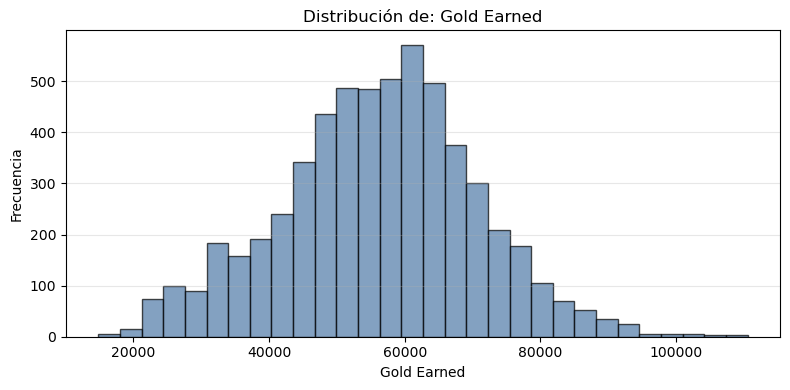

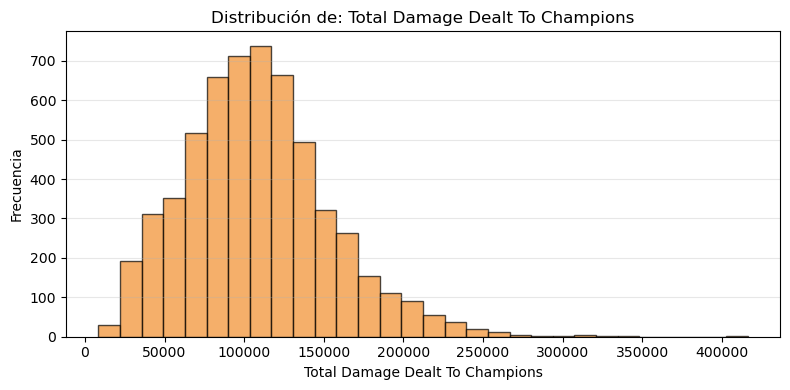

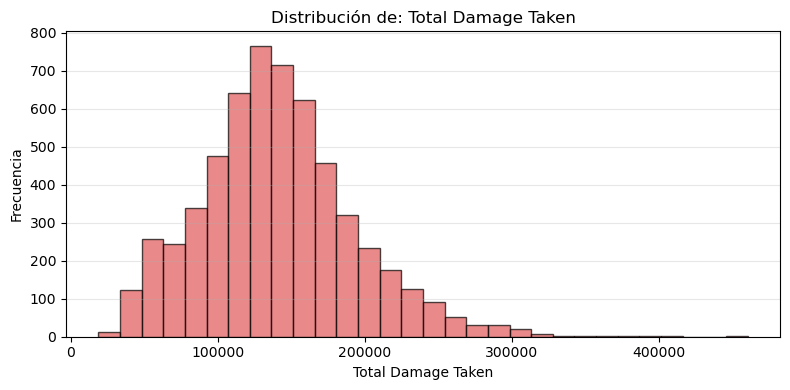

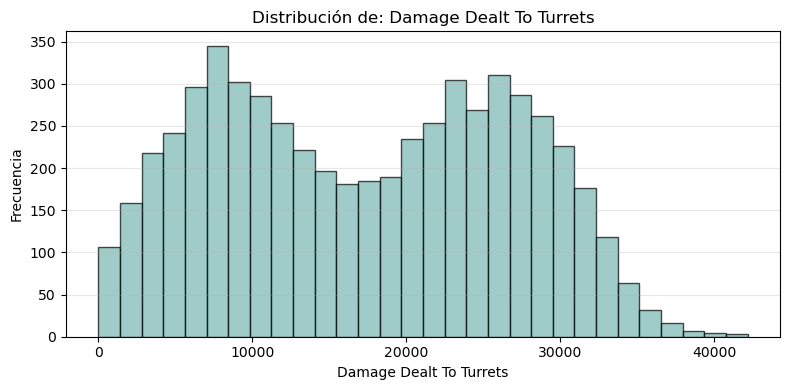

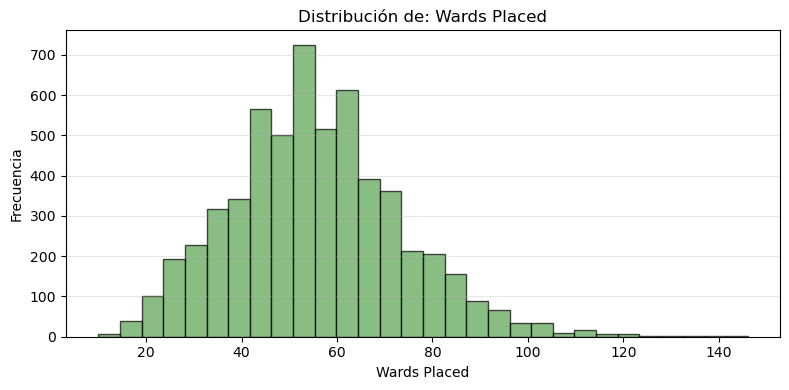

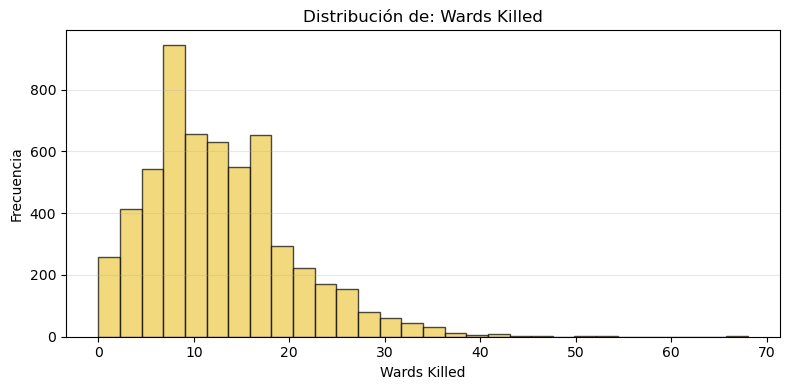

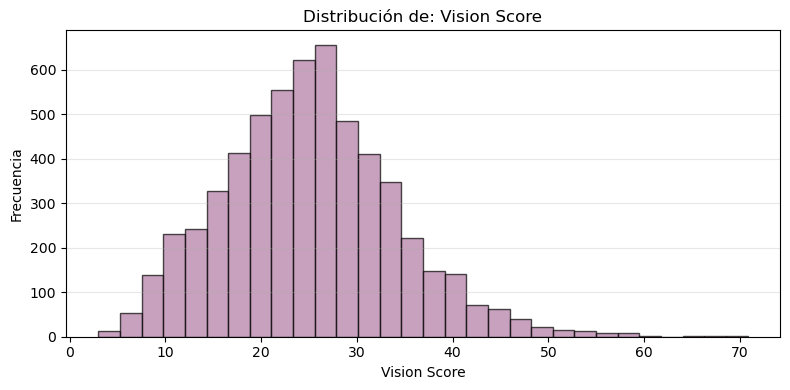

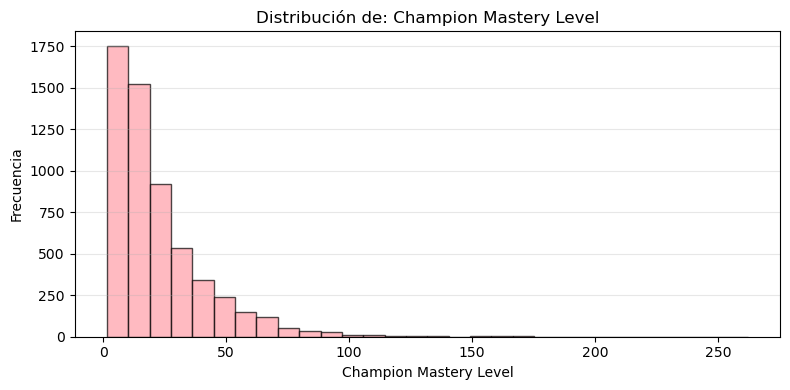

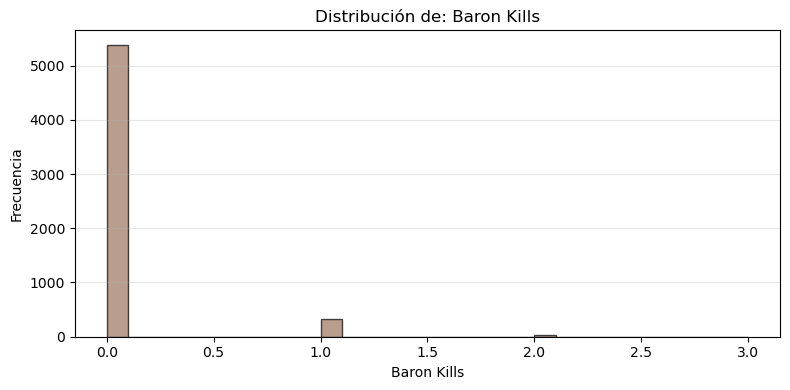

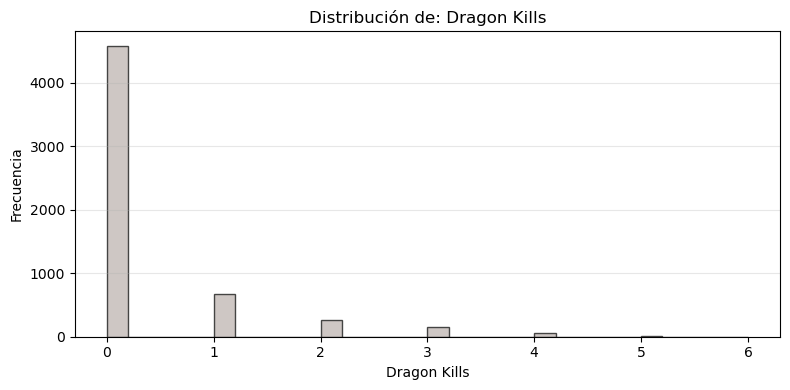

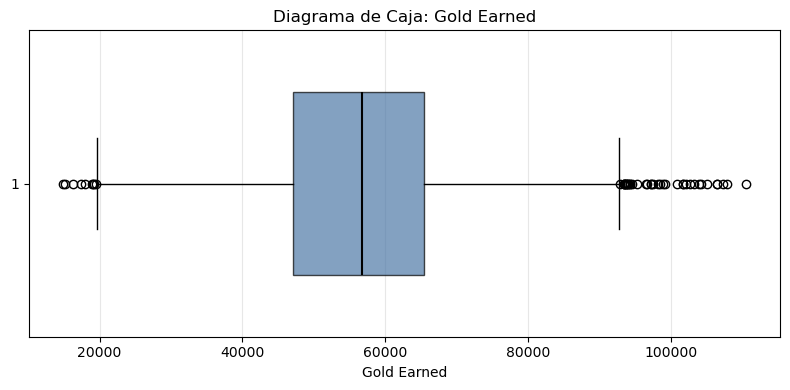

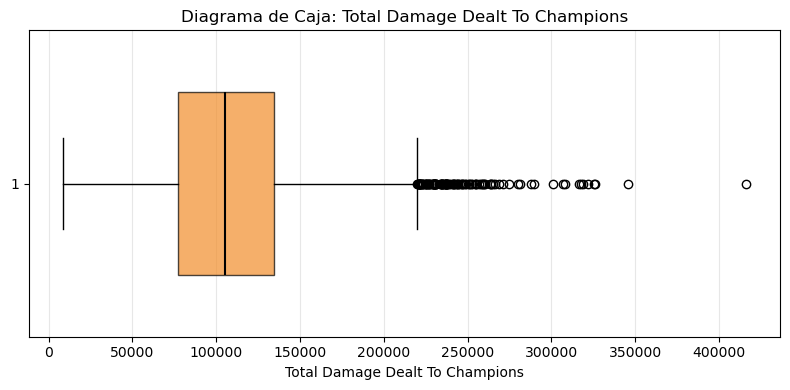

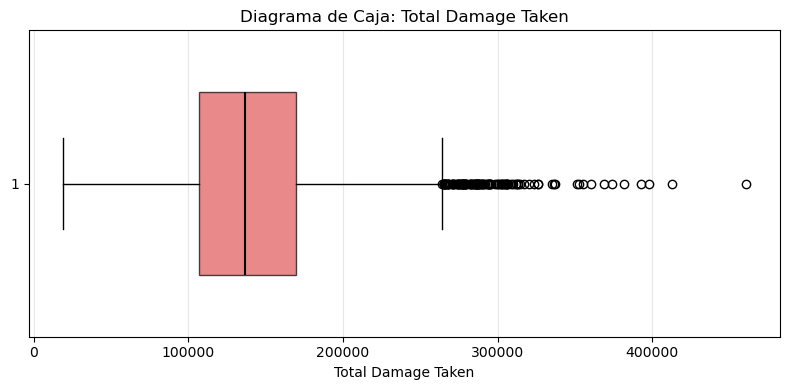

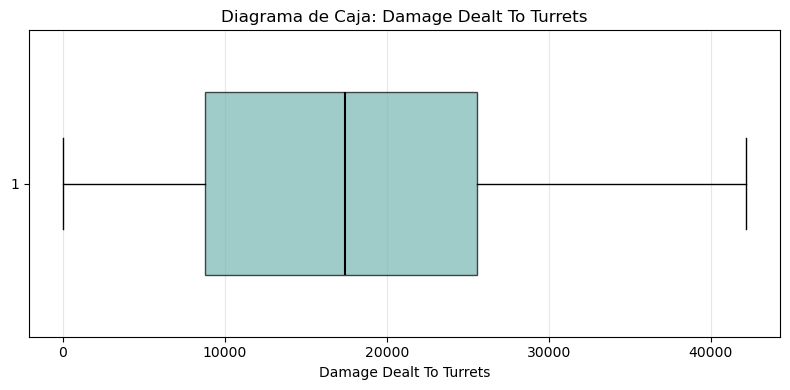

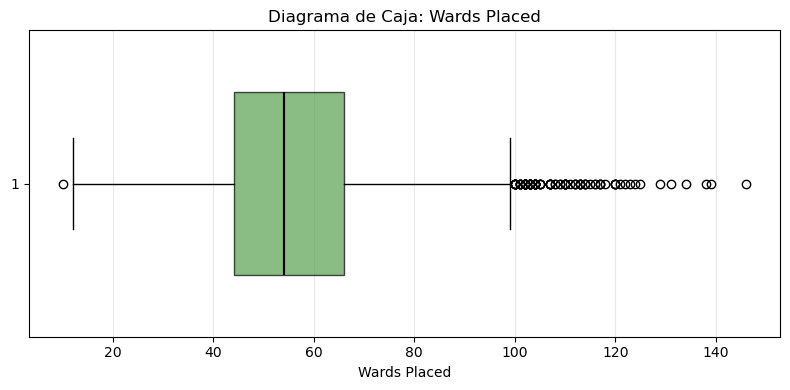

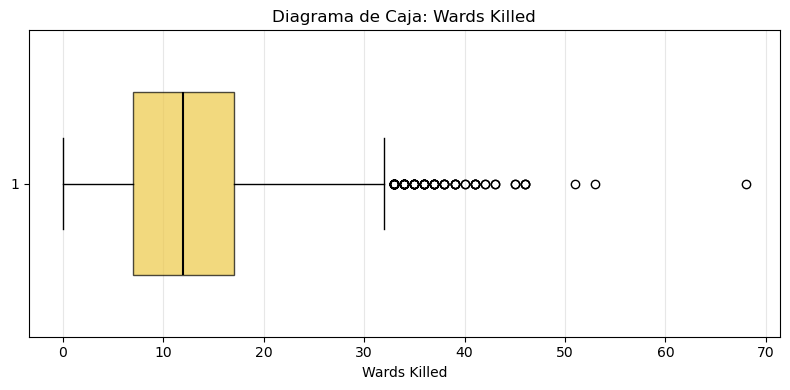

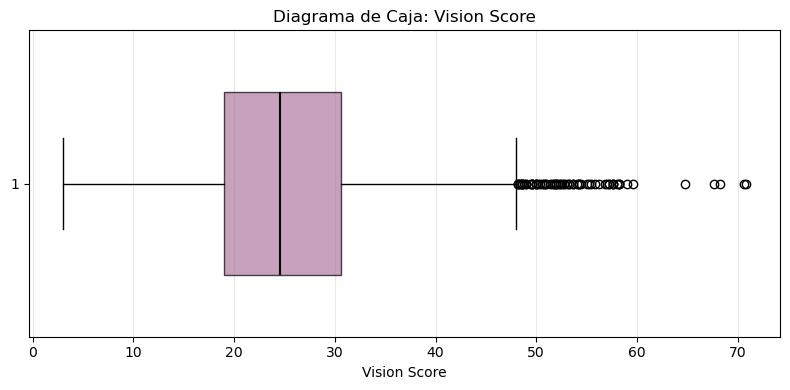

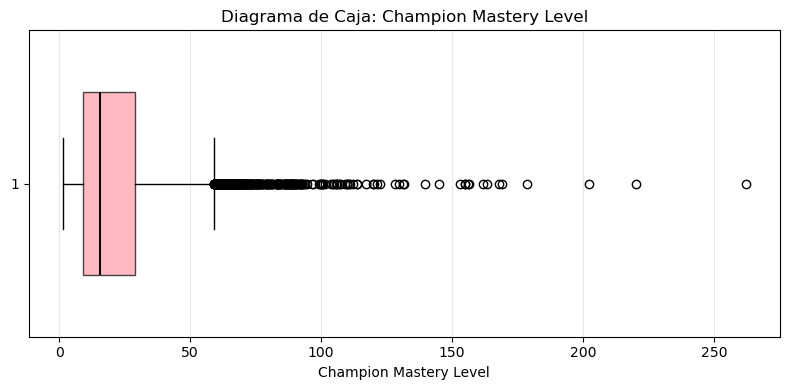

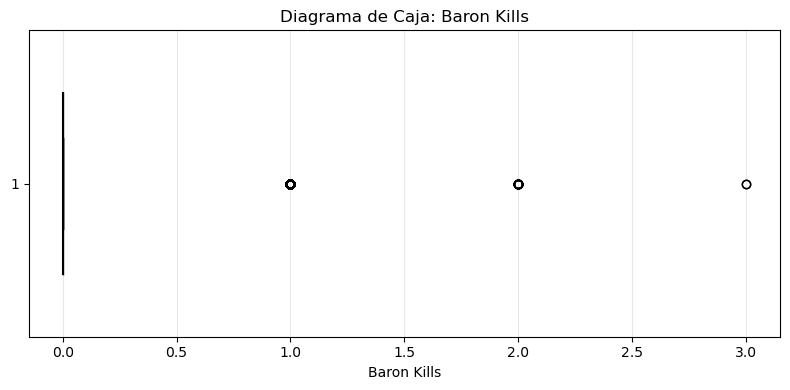

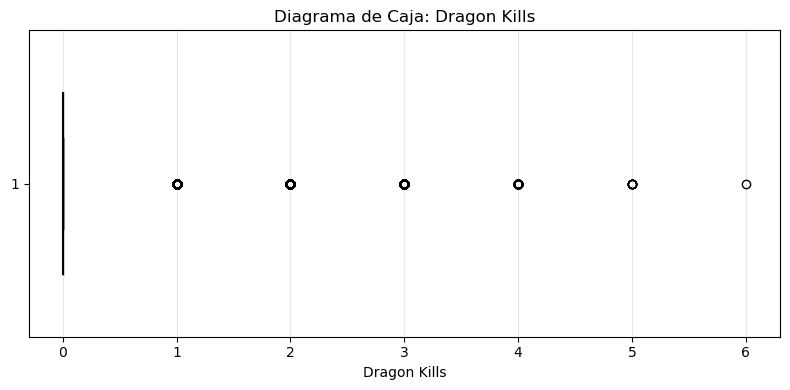

,media,desviacion_estandar,minimo,q1,mediana,q3,maximo
gold_earned,56116.733299,14476.415845,14839.0,47084.5,56715.0,65420.00,110541.0
total_damage_dealt_to_champions,108549.180237,45777.923158,8478.0,77313.5,105170.5,134270.50,415982.0
total_damage_taken,140469.040014,52411.503629,18785.0,106808.0,136898.0,169674.75,460492.0
damage_dealt_to_turrets,17326.174669,9550.107086,0.0,8767.0,17433.5,25563.50,42167.0
wards_placed,55.531489,17.907411,10.0,44.0,54.0,66.00,146.0
wards_killed,12.712248,7.442162,0.0,7.0,12.0,17.00,68.0
vision_score,25.046973,9.031451,3.0,19.0,24.6,30.60,70.8
champion_mastery_level,22.433751,20.096482,1.4,9.0,15.7,29.00,262.2
baron_kills,0.070111,0.280056,0.0,0.0,0.0,0.00,3.0
dragon_kills,0.340640,0.795304,0.0,0.0,0.0,0.00,6.0


In [ ]:
def seccion_2_estadistica_descriptiva(ruta_entrada, ruta_salida):
    """
    Calcula estadísticas descriptivas y genera visualizaciones básicas
    para el dataset agregado a nivel equipo–partida.

    Parámetros:
    - ruta_entrada (str): Ruta del archivo CSV limpio generado en la Sección 1.
    - ruta_salida (str): Ruta del archivo CSV donde se guardarán los estadísticos.

    Retorna:
    - descriptivos (DataFrame): Tabla resumen con las estadísticas calculadas.
    """

    # Se carga el dataset procesado en la etapa anterior
    datos = pd.read_csv(ruta_entrada)
    datos.columns = datos.columns.str.strip()

    # Se definen las variables cuantitativas objeto de estudio
    variables_analisis = [
        "gold_earned",
        "total_damage_dealt_to_champions",
        "total_damage_taken",
        "damage_dealt_to_turrets",
        "wards_placed",
        "wards_killed",
        "vision_score",
        "champion_mastery_level",
        "baron_kills",
        "dragon_kills"
    ]

    # Se calculan las medidas de tendencia central y posición
    descriptivos = datos[variables_analisis].describe(
        percentiles=[0.25, 0.5, 0.75]
    ).T

    # Se seleccionan y ordenan las columnas de interés
    descriptivos = descriptivos[
        ["mean", "std", "min", "25%", "50%", "75%", "max"]
    ]

    # Se renombran las columnas para mantener consistencia en español
    descriptivos.rename(
        columns={
            "mean": "media",
            "std": "desviacion_estandar",
            "min": "minimo",
            "25%": "q1",
            "50%": "mediana",
            "75%": "q3",
            "max": "maximo"
        },
        inplace=True
    )

    # Se exporta la tabla de estadísticos para su posterior consulta
    descriptivos.to_csv(ruta_salida)

    # Se define una paleta de colores de estilo académico para las visualizaciones
    colores_academicos = [
        '#4E79A7', '#F28E2B', '#E15759', '#76B7B2', '#59A14F',
        '#EDC948', '#B07AA1', '#FF9DA7', '#9C755F', '#BAB0AC'
    ]

    # Se generan los histogramas para analizar la frecuencia de cada variable
    for i, variable in enumerate(variables_analisis):
        # Se selecciona el color correspondiente según el índice de la variable
        color_actual = colores_academicos[i % len(colores_academicos)]

        # Se formatea el nombre de la variable para una presentación más limpia en el título
        titulo_formateado = variable.replace("_", " ").title()

        plt.figure(figsize=(8, 4))
        # Se crea el histograma con bordes definidos para claridad visual
        plt.hist(datos[variable], bins=30, color=color_actual, edgecolor='black', alpha=0.7)
        plt.xlabel(titulo_formateado)
        plt.ylabel("Frecuencia")
        plt.title(f"Distribución de: {titulo_formateado}")
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Se generan los diagramas de caja para la detección de valores atípicos
    for i, variable in enumerate(variables_analisis):
        # Se mantiene la consistencia de color con el histograma correspondiente
        color_actual = colores_academicos[i % len(colores_academicos)]
        titulo_formateado = variable.replace("_", " ").title()

        plt.figure(figsize=(8, 4))
        # Se genera el boxplot activando 'patch_artist' para permitir coloreado
        caja = plt.boxplot(datos[variable], vert=False, patch_artist=True, widths=0.6)

        # Se aplica el color seleccionado al cuerpo de la caja
        for patch in caja['boxes']:
            patch.set_facecolor(color_actual)
            patch.set_alpha(0.7)

        # Se personalizan los elementos restantes (medianas, bigotes) para mayor contraste
        plt.setp(caja['medians'], color='black', linewidth=1.5)
        plt.setp(caja['whiskers'], color='black', linewidth=1)
        plt.setp(caja['caps'], color='black', linewidth=1)

        plt.xlabel(titulo_formateado)
        plt.title(f"Diagrama de Caja: {titulo_formateado}")
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

    return descriptivos

# Se ejecuta la función para generar los reportes de la Sección 2
tabla_descriptivos = seccion_2_estadistica_descriptiva(
    ruta_entrada="league_data_etapa1_limpio_equipo.csv",
    ruta_salida="league_data_etapa2_estadisticos.csv"
)

# Se visualiza la tabla resultante
tabla_descriptivos

### Sección 3: Normalización de los Datos (Z-Score)

En esta etapa se lleva a cabo la estandarización de las variables numéricas mediante la técnica de *Z-score*. El propósito fundamental es reescalar las métricas para que todas compartan una escala común (media de 0 y desviación estándar de 1), eliminando así los sesgos introducidos por las diferencias de magnitud entre variables (por ejemplo, la diferencia de escala entre "Oro Ganado" y "Puntuación de Visión").

La transformación matemática aplicada a cada valor $x$ es:

$$Z = \frac{x - \mu}{\sigma}$$

Donde $\mu$ representa la media poblacional y $\sigma$ la desviación estándar de la variable. Adicionalmente, el algoritmo incluye un mecanismo de control para gestionar variables con varianza nula ($\sigma = 0$), asignándoles un valor neutro para evitar errores matemáticos por indefinición.
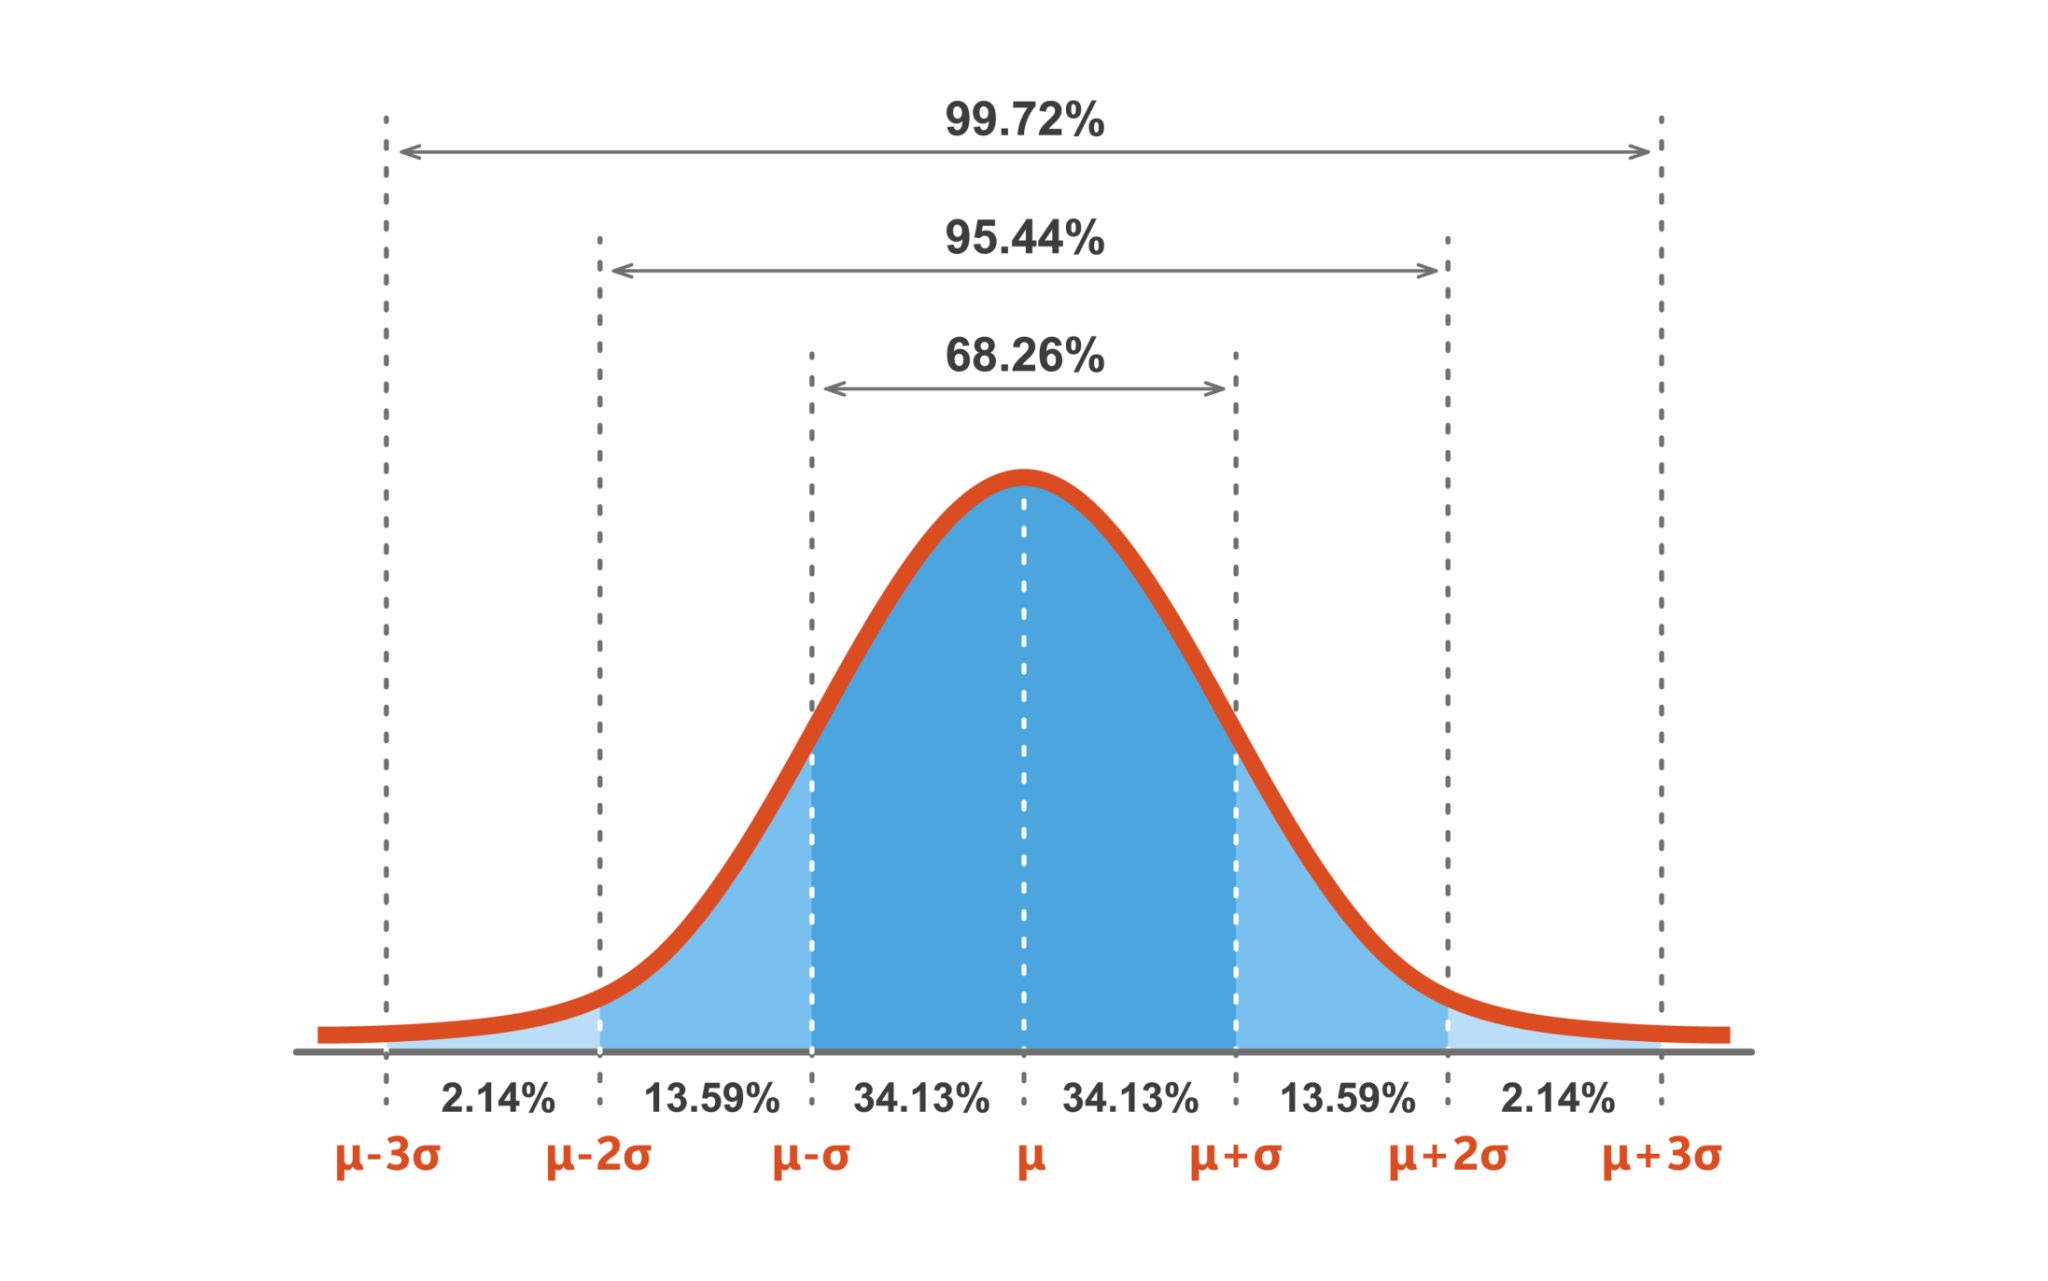

In [ ]:
def seccion_3_normalizacion_zscore(ruta_entrada, ruta_salida):
    """
    Aplica normalización Z-score a las variables numéricas del dataset
    agregado a nivel equipo–partida.

    Parámetros:
    - ruta_entrada (str): Ruta del archivo CSV generado en la Sección 1.
    - ruta_salida (str): Ruta del archivo CSV normalizado.

    Retorna:
    - datos_normalizados (DataFrame): Dataset con variables transformadas.
    """

    # Se carga el dataset agregado previamente procesado
    datos = pd.read_csv(ruta_entrada)
    datos.columns = datos.columns.str.strip()

    # Se seleccionan las variables cuantitativas sujetas a normalización
    # Se excluyen identificadores y la variable objetivo binaria
    variables_normalizar = [
        "gold_earned",
        "total_damage_dealt_to_champions",
        "total_damage_taken",
        "damage_dealt_to_turrets",
        "wards_placed",
        "wards_killed",
        "vision_score",
        "champion_mastery_level",
        "baron_kills",
        "dragon_kills"
    ]

    # Se crea una copia independiente para preservar los datos originales
    datos_normalizados = datos.copy()

    # Se ejecuta el cálculo de Z-score iterando sobre cada variable
    for variable in variables_normalizar:
        media = datos[variable].mean()
        desviacion = datos[variable].std()

        # Se implementa una validación para evitar la división por cero
        if desviacion == 0:
            datos_normalizados[variable] = 0
        else:
            # Se aplica la fórmula de estandarización
            datos_normalizados[variable] = (
                datos[variable] - media
            ) / desviacion

    # Se exporta el dataset normalizado a la ruta especificada
    datos_normalizados.to_csv(ruta_salida, index=False)

    return datos_normalizados

# Se ejecuta la función correspondiente a la Sección 3
datos_normalizados = seccion_3_normalizacion_zscore(
    ruta_entrada="league_data_etapa1_limpio_equipo.csv",
    ruta_salida="league_data_etapa3_normalizado.csv"
)

# Se visualizan las primeras filas para verificar la transformación
datos_normalizados.head()

,game_id,team_id,gold_earned,total_damage_dealt_to_champions,total_damage_taken,damage_dealt_to_turrets,wards_placed,wards_killed,vision_score,champion_mastery_level,baron_kills,dragon_kills,win
0,3.551608e+09,100.0,0.804637,0.465417,-0.079754,-0.055306,2.036504,-0.498813,1.146330,-0.409711,-0.250348,-0.428314,0
1,3.551608e+09,200.0,0.701435,-0.013526,0.399778,0.794632,1.031333,0.576143,1.367779,0.018225,-0.250348,-0.428314,1
2,3.554098e+09,100.0,-1.207739,-1.101015,-1.006001,-1.320213,-1.369907,-1.305030,-1.356036,-0.558991,-0.250348,-0.428314,0
3,3.554098e+09,200.0,-0.861037,-0.890761,-1.190369,-0.680534,-1.649121,-0.633183,-1.378181,-0.817743,-0.250348,-0.428314,1
4,3.554142e+09,100.0,0.498761,0.346539,0.858589,0.471285,0.193691,0.441774,0.703434,-0.947119,-0.250348,-0.428314,0


### Sección 4: Formulación del Sistema Normal de Mínimos Cuadrados

En esta fase se construye el modelo matemático lineal que relaciona las variables predictoras (métricas de juego) con la variable objetivo (victoria/derrota). El método utilizado es el de **Mínimos Cuadrados Ordinarios**, el cual busca minimizar la suma de los errores al cuadrado entre las observaciones reales y las predicciones del modelo.

El sistema se plantea matricialmente mediante las **Ecuaciones Normales**:

$$X^T X \hat{\beta} = X^T y$$

Donde:
* **$X$ (Matriz de Diseño):** Contiene los datos de las variables independientes, incluyendo una columna de unos ($1$) para el término del intercepto ($\beta_0$).
* **$y$ (Vector Objetivo):** Contiene los resultados reales de las partidas.
* **$X^T X$ (Matriz de Gram):** Matriz cuadrada simétrica que resume la varianza y covarianza de los predictores.
* **$X^T y$:** Vector de proyección de $y$ sobre el espacio de columnas de $X$.

El objetivo de esta sección es calcular las matrices $A = X^T X$ y $b = X^T y$ para preparar la resolución del sistema lineal.

In [30]:
def seccion_4_sistema_normal(ruta_normalizado, imprimir_ecuaciones=True):
    """
    Construye el sistema de ecuaciones normales para el ajuste por mínimos cuadrados.
    Utiliza precisión completa para los cálculos matriciales y presenta los
    resultados con redondeo únicamente para visualización.

    Parámetros:
    - ruta_normalizado (str): Ruta del archivo CSV con los datos estandarizados.
    - imprimir_ecuaciones (bool): Controla la visualización de las ecuaciones resultantes.

    Retorna:
    - X (numpy.ndarray): Matriz de diseño con intercepto incluido.
    - y (numpy.ndarray): Vector de la variable dependiente.
    - A (numpy.ndarray): Matriz de coeficientes del sistema normal (X^T * X).
    - b (numpy.ndarray): Vector de términos independientes del sistema normal (X^T * y).
    - variables_predictoras (list): Lista de nombres de las variables analizadas.
    """

    # Se realiza la carga del conjunto de datos normalizado
    datos = pd.read_csv(ruta_normalizado)
    datos.columns = datos.columns.str.strip()

    # Se definen las variables independientes que conformarán la matriz de diseño
    variables_predictoras = [
        "baron_kills",
        "dragon_kills",
        "vision_score",
        "wards_placed",
        "wards_killed",
        "damage_dealt_to_turrets",
        "gold_earned",
        "total_damage_dealt_to_champions",
        "total_damage_taken",
        "champion_mastery_level"
    ]

    # Se valida la integridad del dataset asegurando la existencia de todas las columnas
    faltantes = [c for c in variables_predictoras + ["win"] if c not in datos.columns]
    if faltantes:
        raise KeyError("Faltan columnas en el dataset: " + ", ".join(faltantes))

    # Se construyen los vectores y matrices base para el cálculo
    y = datos["win"].values.reshape(-1, 1)
    X_sin_intercepto = datos[variables_predictoras].values

    # Se añade una columna de unos a la matriz X para representar el intercepto (beta_0)
    X = np.hstack([
        np.ones((X_sin_intercepto.shape[0], 1)),
        X_sin_intercepto
    ])

    # Se calculan los componentes del sistema normal: A = X^T * X y b = X^T * y
    A = X.T @ X
    b = X.T @ y

    # Se reportan las dimensiones de las estructuras algebraicas generadas
    print("SECCIÓN 4: SISTEMA NORMAL DE MÍNIMOS CUADRADOS")
    print("-" * 46)
    print(f"Observaciones (n): {X.shape[0]}")
    print(f"Variables predictoras (p): {len(variables_predictoras)}")
    print(f"Dimensión de X: {X.shape}")
    print(f"Dimensión de y: {y.shape}")
    print(f"Dimensión de A = X^T X: {A.shape}")
    print(f"Dimensión de b = X^T y: {b.shape}")
    print("-" * 46 + "\n")

    # Se procede a imprimir las ecuaciones lineales resultantes si se solicita
    if imprimir_ecuaciones:
        nombres_coef = ["β0"] + [f"β{i}" for i in range(1, len(variables_predictoras) + 1)]

        print("ECUACIONES NORMALES (A · β = b)")
        print("Mapa de coeficientes:")
        print("β0 = intercepto")
        for i, var in enumerate(variables_predictoras, start=1):
            print(f"β{i} = {var}")
        print("\n")

        for i in range(A.shape[0]):
            terminos = []
            for j in range(A.shape[1]):
                # Se formatean los coeficientes a 5 decimales para facilitar la lectura
                terminos.append(f"({A[i, j]:.5f}){nombres_coef[j]}")
            ecuacion = " + ".join(terminos) + f" = ({b[i, 0]:.5f})"
            print(f"Ecuación {i+1}: {ecuacion}\n")

    return X, y, A, b, variables_predictoras

# Se ejecuta la función para obtener las matrices del sistema
X, y, A, b, variables_predictoras = seccion_4_sistema_normal(
    "league_data_etapa3_normalizado.csv",
    imprimir_ecuaciones=True
)

SECCIÓN 4: SISTEMA NORMAL DE MÍNIMOS CUADRADOS
----------------------------------------------
Observaciones (n): 5748
Variables predictoras (p): 10
Dimensión de X: (5748, 11)
Dimensión de y: (5748, 1)
Dimensión de A = X^T X: (11, 11)
Dimensión de b = X^T y: (11, 1)
----------------------------------------------

ECUACIONES NORMALES (A · β = b)
Mapa de coeficientes:
β0 = intercepto
β1 = baron_kills
β2 = dragon_kills
β3 = vision_score
β4 = wards_placed
β5 = wards_killed
β6 = damage_dealt_to_turrets
β7 = gold_earned
β8 = total_damage_dealt_to_champions
β9 = total_damage_taken
β10 = champion_mastery_level


Ecuación 1: (5748.00000)β0 + (0.00000)β1 + (-0.00000)β2 + (-0.00000)β3 + (0.00000)β4 + (0.00000)β5 + (0.00000)β6 + (-0.00000)β7 + (0.00000)β8 + (-0.00000)β9 + (0.00000)β10 = (2875.00000)

Ecuación 2: (0.00000)β0 + (5747.00000)β1 + (2553.41797)β2 + (1250.24887)β3 + (1169.23595)β4 + (879.92731)β5 + (1008.71789)β6 + (1434.58653)β7 + (1221.76943)β8 + (1022.63373)β9 + (129.59846)β10 = (458.5

### Sección 5: Resolución y Comparación de Métodos Numéricos

En esta etapa se busca determinar el método numérico más eficiente para resolver el sistema de ecuaciones normales $A\beta = b$. Se implementan y comparan cinco algoritmos distintos, incluyendo métodos directos (exactos) y métodos iterativos (aproximados).

Es importante notar que los métodos iterativos (**Jacobi** y **Gauss-Seidel**) solo garantizan convergencia si la matriz $A$ es estrictamente diagonal dominante o definida positiva. Dado que no siempre se cumple esta condición en datos reales, se ha implementado un **mecanismo de seguridad** que detecta la divergencia (crecimiento descontrolado de los valores) e interrumpe el proceso para evitar desbordamientos numéricos.

**Criterio de Selección:**
El algoritmo evalúa el tiempo de ejecución y la norma del residual ($||A\hat{x} - b||$). Se selecciona automáticamente el método que ofrezca el menor tiempo de cómputo, siempre y cuando:
1.  El método haya convergido exitosamente (sin errores ni divergencia).
2.  Su error residual se mantenga por debajo de la tolerancia predefinida ($1 \times 10^{-6}$).

Finalmente, se calculan las métricas de desempeño del modelo (SSE y MSE) utilizando los coeficientes del método ganador.

In [34]:
def seccion_5_comparar_metodos(A, b, X, y, variables_predictoras,
                               tolerancia=1e-8, max_iter=5000,
                               imprimir_resultados=True):
    """
    Resuelve el sistema A*beta=b comparando múltiples métodos numéricos.
    Incluye protección contra divergencia en métodos iterativos.

    Parámetros:
    - A, b: Coeficientes del sistema lineal.
    - X, y: Datos originales para cálculo de métricas.
    - variables_predictoras: Lista de nombres de las variables.
    - tolerancia: Umbral de convergencia.
    - max_iter: Límite de iteraciones.

    Retorna:
    - Resultados comparativos y el modelo del método óptimo.
    """

    # Se aseguran los tipos de datos y copias independientes
    A = np.array(A, dtype=float).copy()
    b = np.array(b, dtype=float).reshape(-1, 1).copy()

    n = A.shape[0]

    # Se validan las dimensiones básicas
    if A.shape[0] != A.shape[1]:
        raise ValueError("A debe ser cuadrada.")
    if b.shape[0] != n:
        raise ValueError("Dimensiones incompatibles entre A y b.")

    # Lista para almacenar las métricas de desempeño
    resultados = []

    def gauss_pivoteo(A_local, b_local):
        """Implementa eliminación Gaussiana con pivoteo parcial."""
        Ab = np.hstack([A_local.copy(), b_local.copy()])
        n_local = Ab.shape[0]

        for k in range(n_local - 1):
            pivote = np.argmax(np.abs(Ab[k:, k])) + k
            if Ab[pivote, k] == 0:
                raise ValueError("Pivote cero (singular).")

            if pivote != k:
                Ab[[k, pivote]] = Ab[[pivote, k]]

            for i in range(k + 1, n_local):
                factor = Ab[i, k] / Ab[k, k]
                Ab[i, k:] -= factor * Ab[k, k:]

        beta = np.zeros((n_local, 1))
        for i in range(n_local - 1, -1, -1):
            if Ab[i, i] == 0:
                raise ValueError("Cero en diagonal.")
            beta[i] = (Ab[i, -1] - np.dot(Ab[i, i+1:n_local], beta[i+1:n_local])) / Ab[i, i]
        return beta

    def gauss_jordan(A_local, b_local):
        """Implementa el método de Gauss-Jordan."""
        Ab = np.hstack([A_local.copy(), b_local.copy()])
        n_local = Ab.shape[0]

        for k in range(n_local):
            pivote = np.argmax(np.abs(Ab[k:, k])) + k
            if Ab[pivote, k] == 0:
                raise ValueError("Pivote cero (singular).")
            if pivote != k:
                Ab[[k, pivote]] = Ab[[pivote, k]]

            # Se normaliza la fila del pivote
            Ab[k, :] = Ab[k, :] / Ab[k, k]

            # Se eliminan los elementos en todas las demás filas
            for i in range(n_local):
                if i != k:
                    factor = Ab[i, k]
                    Ab[i, :] -= factor * Ab[k, :]

        beta = Ab[:, -1].reshape(-1, 1)
        return beta

    def lu_doolittle(A_local):
        """Realiza la descomposición LU mediante algoritmo de Doolittle."""
        n_local = A_local.shape[0]
        L = np.eye(n_local)
        U = np.zeros((n_local, n_local))

        for i in range(n_local):
            for j in range(i, n_local):
                U[i, j] = A_local[i, j] - np.dot(L[i, :i], U[:i, j])
            if U[i, i] == 0:
                raise ValueError("Cero en diagonal de U.")

            for j in range(i + 1, n_local):
                L[j, i] = (A_local[j, i] - np.dot(L[j, :i], U[:i, i])) / U[i, i]

        return L, U

    def lu_resolver(A_local, b_local):
        """Resuelve el sistema usando factorización LU."""
        def sustitucion_adelante(L, b_local):
            n_local = L.shape[0]
            z = np.zeros((n_local, 1))
            for i in range(n_local):
                z[i] = b_local[i] - np.dot(L[i, :i], z[:i])
            return z

        def sustitucion_atras(U, z):
            n_local = U.shape[0]
            x = np.zeros((n_local, 1))
            for i in range(n_local - 1, -1, -1):
                if U[i, i] == 0:
                    raise ValueError("Cero en diagonal de U.")
                x[i] = (z[i] - np.dot(U[i, i+1:], x[i+1:])) / U[i, i]
            return x

        L, U = lu_doolittle(A_local.copy())
        z = sustitucion_adelante(L, b_local.copy())
        beta = sustitucion_atras(U, z)
        return beta

    def jacobi(A_local, b_local, tol, it_max):
        """Resuelve mediante Jacobi con control de divergencia."""
        n_local = A_local.shape[0]
        x = np.zeros((n_local, 1))
        D = np.diag(A_local)
        if np.any(D == 0):
            raise ValueError("Cero en diagonal (Jacobi no aplicable).")

        R = A_local - np.diagflat(D)

        for it in range(1, it_max + 1):
            x_new = (b_local - R @ x) / D.reshape(-1, 1)

            # Se verifica si hay desbordamiento numérico o valores indefinidos
            if np.any(np.isnan(x_new)) or np.any(np.isinf(x_new)):
                raise ValueError("Divergencia detectada (valores infinitos).")

            # Se verifica si la solución crece demasiado (límite de seguridad)
            if np.linalg.norm(x_new) > 1e15:
                raise ValueError("Divergencia detectada (solución inestable).")

            if np.linalg.norm(x_new - x, ord=np.inf) < tol:
                return x_new, it
            x = x_new
        return x, it_max

    def gauss_seidel(A_local, b_local, tol, it_max):
        """Resuelve mediante Gauss-Seidel con control de divergencia."""
        n_local = A_local.shape[0]
        x = np.zeros((n_local, 1))

        for it in range(1, it_max + 1):
            x_old = x.copy()
            for i in range(n_local):
                if A_local[i, i] == 0:
                    raise ValueError("Cero en diagonal (Seidel no aplicable).")
                suma1 = np.dot(A_local[i, :i], x[:i])
                suma2 = np.dot(A_local[i, i+1:], x_old[i+1:])
                x[i] = (b_local[i] - suma1 - suma2) / A_local[i, i]

            # Se verifica integridad numérica en cada iteración
            if np.any(np.isnan(x)) or np.any(np.isinf(x)):
                raise ValueError("Divergencia detectada (valores infinitos).")
            
            if np.linalg.norm(x) > 1e15:
                raise ValueError("Divergencia detectada (solución inestable).")

            if np.linalg.norm(x - x_old, ord=np.inf) < tol:
                return x, it
        return x, it_max

    def evaluar_metodo(nombre, solver, es_iterativo=False):
        """Ejecuta un solver y captura errores o divergencias."""
        try:
            t0 = time.perf_counter()

            if es_iterativo:
                beta, iters = solver(A, b, tolerancia, max_iter)
            else:
                beta = solver(A, b)
                iters = None

            t1 = time.perf_counter()
            tiempo = t1 - t0

            residual = A @ beta - b
            norma_res = float(np.linalg.norm(residual, ord=2))

            resultados.append({
                "metodo": nombre,
                "tiempo_s": tiempo,
                "iteraciones": iters if iters is not None else "",
                "norma_residual": norma_res,
                "estado": "OK"
            })
            return beta

        except Exception as e:
            # Se registra el error sin detener la ejecución global
            resultados.append({
                "metodo": nombre,
                "tiempo_s": np.nan,
                "iteraciones": "",
                "norma_residual": np.nan,
                "estado": f"FALLO: {str(e)}"
            })
            return None

    # Se ejecutan las evaluaciones de todos los métodos
    beta_gauss = evaluar_metodo("Gauss (pivoteo parcial)", gauss_pivoteo, es_iterativo=False)
    beta_gj    = evaluar_metodo("Gauss-Jordan", gauss_jordan, es_iterativo=False)
    beta_lu    = evaluar_metodo("LU (Doolittle)", lu_resolver, es_iterativo=False)
    beta_jac   = evaluar_metodo("Jacobi", jacobi, es_iterativo=True)
    beta_gs    = evaluar_metodo("Gauss-Seidel", gauss_seidel, es_iterativo=True)

    tabla = pd.DataFrame(resultados)

    # Se seleccionan los candidatos válidos (Estado OK y residual bajo)
    umbral_residual = 1e-6
    candidatos = tabla[(tabla["estado"] == "OK") & (tabla["norma_residual"] <= umbral_residual)].copy()

    if candidatos.empty:
        # Fallback: se elige el método que no falló con menor residual
        ok = tabla[tabla["estado"] == "OK"].copy()
        if ok.empty:
            raise ValueError("Todos los métodos fallaron. Revisar matriz A.")
        mejor_fila = ok.sort_values(["norma_residual", "tiempo_s"], ascending=[True, True]).iloc[0]
        criterio = "Menor residual (no se alcanzó tolerancia)"
    else:
        # Se elige el más rápido de los válidos
        mejor_fila = candidatos.sort_values("tiempo_s", ascending=True).iloc[0]
        criterio = "Menor tiempo (con convergencia exitosa)"

    metodo_ganador = mejor_fila["metodo"]

    # Se recupera el vector beta del método ganador
    mapa_beta = {
        "Gauss (pivoteo parcial)": beta_gauss,
        "Gauss-Jordan": beta_gj,
        "LU (Doolittle)": beta_lu,
        "Jacobi": beta_jac,
        "Gauss-Seidel": beta_gs
    }
    beta = mapa_beta[metodo_ganador]

    # Se calculan las métricas finales del modelo
    y_hat = X @ beta
    r = y - y_hat
    SSE = float((r.T @ r)[0, 0])
    MSE = SSE / X.shape[0]

    nombres_coef = ["intercepto"] + variables_predictoras
    betas = beta.flatten()

    tabla_coef = pd.DataFrame({
        "coeficiente": nombres_coef,
        "beta": betas,
        "abs_beta": np.abs(betas)
    })

    ranking = tabla_coef[tabla_coef["coeficiente"] != "intercepto"] \
        .sort_values("abs_beta", ascending=False) \
        .reset_index(drop=True)

    if imprimir_resultados:
        print("SECCIÓN 5: COMPARACIÓN DE MÉTODOS Y SELECCIÓN")
        print(f"Criterio de selección: {criterio}")
        print(f"Método seleccionado: {metodo_ganador}")
        print("")

        print("Tabla comparativa de rendimiento:")
        tabla_mostrar = tabla.copy()
        tabla_mostrar["tiempo_s"] = tabla_mostrar["tiempo_s"].round(5)
        tabla_mostrar["norma_residual"] = tabla_mostrar["norma_residual"].round(5)
        display(tabla_mostrar)

        print(f"\nCoeficientes calculados con {metodo_ganador} (redondeo 5 decimales):")
        tabla_coef_mostrar = tabla_coef.copy()
        tabla_coef_mostrar["beta"] = tabla_coef_mostrar["beta"].round(5)
        tabla_coef_mostrar["abs_beta"] = tabla_coef_mostrar["abs_beta"].round(5)
        display(tabla_coef_mostrar)

        print("\nMétricas de error del ajuste:")
        print(f"SSE: {SSE:.5f}")
        print(f"MSE: {MSE:.5f}")

        print("\nRanking de importancia (|beta|) sin intercepto:")
        ranking_mostrar = ranking.copy()
        ranking_mostrar["beta"] = ranking_mostrar["beta"].round(5)
        ranking_mostrar["abs_beta"] = ranking_mostrar["abs_beta"].round(5)
        display(ranking_mostrar)

    return metodo_ganador, beta, y_hat, r, SSE, MSE, tabla, tabla_coef, ranking

# Se ejecuta la comparación y resolución del sistema
metodo_ganador, beta, y_hat, r, SSE, MSE, tabla, tabla_coef, ranking = seccion_5_comparar_metodos(
    A, b, X, y, variables_predictoras,
    imprimir_resultados=True
)

SECCIÓN 5: COMPARACIÓN DE MÉTODOS Y SELECCIÓN
Criterio de selección: Menor tiempo (con convergencia exitosa)
Método seleccionado: Gauss (pivoteo parcial)

Tabla comparativa de rendimiento:


,metodo,tiempo_s,iteraciones,norma_residual,estado
0,Gauss (pivoteo parcial),0.00135,,0.00000,OK
1,Gauss-Jordan,0.00192,,0.00000,OK
2,LU (Doolittle),0.00193,,0.00000,OK
3,Jacobi,NaN,,NaN,FALLO: Divergencia detectada (solución inestab...
4,Gauss-Seidel,0.11761,155,0.00006,OK



Coeficientes calculados con Gauss (pivoteo parcial) (redondeo 5 decimales):


,coeficiente,beta,abs_beta
0,intercepto,0.50017,0.50017
1,baron_kills,0.02319,0.02319
2,dragon_kills,0.01494,0.01494
3,vision_score,-0.05760,0.05760
4,wards_placed,-0.01236,0.01236
5,wards_killed,0.00361,0.00361
6,damage_dealt_to_turrets,0.29791,0.29791
7,gold_earned,0.17971,0.17971
8,total_damage_dealt_to_champions,0.15941,0.15941
9,total_damage_taken,-0.37382,0.37382



Métricas de error del ajuste:
SSE: 458.24446
MSE: 0.07972

Ranking de importancia (|beta|) sin intercepto:


,coeficiente,beta,abs_beta
0,total_damage_taken,-0.37382,0.37382
1,damage_dealt_to_turrets,0.29791,0.29791
2,gold_earned,0.17971,0.17971
3,total_damage_dealt_to_champions,0.15941,0.15941
4,vision_score,-0.05760,0.05760
5,baron_kills,0.02319,0.02319
6,dragon_kills,0.01494,0.01494
7,wards_placed,-0.01236,0.01236
8,wards_killed,0.00361,0.00361
9,champion_mastery_level,-0.00253,0.00253


### Sección 6: Generación de Predicciones y Cálculo de Error

En esta fase se pone a prueba el modelo predictivo aplicando la ecuación de regresión lineal obtenida. Se utilizan los coeficientes fijos ($\beta$) determinados en el análisis previo para estimar la probabilidad de victoria ($\hat{y}$) de cada equipo basándose en sus métricas normalizadas.

La ecuación del modelo se define como:
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

Posteriormente, se cuantifica la precisión del modelo calculando los residuales (la diferencia entre el resultado real y el predicho). Se reportan las métricas de error global:
* **SSE (Suma de Errores al Cuadrado):** Magnitud total del error en el dataset.
* **MSE (Error Cuadrático Medio):** Promedio del error al cuadrado, utilizado para validar la consistencia del modelo frente a los resultados obtenidos en la etapa de entrenamiento.

In [36]:
def seccion_6_generar_predicciones(ruta_dataset, beta, variables_predictoras):
    """
    Genera las predicciones del modelo aplicando el producto punto entre
    los datos normalizados y el vector de coeficientes beta calculado previamente.

    Parámetros:
    - ruta_dataset (str): Ruta del archivo CSV con datos normalizados.
    - beta (numpy.ndarray): Vector de coeficientes obtenido en la Sección 5.
    - variables_predictoras (list): Lista de nombres de las columnas a utilizar.

    Retorna:
    - resultado (DataFrame): Tabla con los valores reales, predicciones y errores.
    - SSE (float): Suma de Errores al Cuadrado.
    - MSE (float): Error Cuadrático Medio.
    """

    # Se carga el dataset normalizado
    df = pd.read_csv(ruta_dataset)
    df.columns = df.columns.str.strip()

    # Se separan los componentes del vector de coeficientes de manera segura para NumPy
    # Se utiliza .item() para extraer el valor escalar y evitar DeprecationWarning
    intercepto = beta[0].item()     # Beta_0
    coeficientes = beta[1:]         # Beta_1 hasta Beta_n

    # Se verifica que las variables predictoras existan en el dataframe
    X_matriz = df[variables_predictoras].values

    # Se calcula la predicción mediante producto matricial
    # y_modelo = Intercepto + (Matriz_X * Vector_Coeficientes)
    predicciones = intercepto + (X_matriz @ coeficientes)

    # Se integran las predicciones al dataframe (se aplana el array para coincidir con la Serie)
    df["y_modelo"] = predicciones.flatten()

    # Se estructura el dataframe de resultados
    resultado = df[["win", "y_modelo"]].copy()
    resultado.rename(columns={"win": "y_real"}, inplace=True)

    # Se calculan los errores de predicción
    resultado["error"] = resultado["y_real"] - resultado["y_modelo"]
    resultado["error_cuadrado"] = resultado["error"] ** 2

    # Se exporta el archivo de resultados
    archivo_salida = "resultado_modelo_seccion6.csv"
    resultado.to_csv(archivo_salida, index=False)

    print(f"Archivo generado exitosamente: {archivo_salida}")
    print("Primeras 5 predicciones del modelo dinámico:")
    print(resultado.head())

    # Cálculo de métricas globales de error
    SSE = resultado["error_cuadrado"].sum()
    MSE = resultado["error_cuadrado"].mean()

    print("\nMétricas de Error Global:")
    print(f"SSE = {SSE:.5f}")
    print(f"MSE = {MSE:.5f}")

    return resultado, SSE, MSE

# Se ejecuta la función utilizando los parámetros obtenidos en la Sección 5
df_predicciones, sse_final, mse_final = seccion_6_generar_predicciones(
    ruta_dataset="league_data_etapa3_normalizado.csv",
    beta=beta,
    variables_predictoras=variables_predictoras
)

Archivo generado exitosamente: resultado_modelo_seccion6.csv
Primeras 5 predicciones del modelo dinámico:
   y_real  y_modelo     error  error_cuadrado
0       0  0.628139 -0.628139        0.394558
1       1  0.609657  0.390343        0.152368
2       0  0.169914 -0.169914        0.028871
3       1  0.533033  0.466967        0.218058
4       0  0.413369 -0.413369        0.170874

Métricas de Error Global:
SSE = 458.24446
MSE = 0.07972


### Sección 7: Validación del Modelo y Métricas de Desempeño

En esta etapa final se evalúa la capacidad predictiva del modelo. Para garantizar la coherencia matemática con las etapas previas, el **umbral de decisión** no se fija arbitrariamente en 0.5, sino que se define dinámicamente utilizando el **intercepto ($\beta_0$)** calculado en la Sección 5.

Dado que las variables predictoras fueron normalizadas (media 0), el intercepto representa la probabilidad base de victoria de un equipo "promedio". Por lo tanto:
* Si $\hat{y} > \beta_0$: El equipo tiene un desempeño superior al promedio $\rightarrow$ Se predice **Victoria (1)**.
* Si $\hat{y} \leq \beta_0$: El equipo tiene un desempeño inferior o igual al promedio $\rightarrow$ Se predice **Derrota (0)**.

Para cuantificar el desempeño, se construye manualmente la **Matriz de Confusión**, la cual desglosa los aciertos y errores en cuatro cuadrantes:
* **Verdaderos Positivos (TP):** Victorias predichas correctamente.
* **Verdaderos Negativos (TN):** Derrotas predichas correctamente.
* **Falsos Positivos (FP):** Partidas donde se predijo victoria pero el equipo perdió (Error Tipo I).
* **Falsos Negativos (FN):** Partidas donde se predijo derrota pero el equipo ganó (Error Tipo II).

A partir de estos valores, se calculan las métricas fundamentales:
* **Exactitud :** Porcentaje global de predicciones correctas.
* **Precisión:** Proporción de victorias predichas que realmente ocurrieron.
* **Sensibilidad :** Capacidad del modelo para detectar las victorias reales.

In [42]:
def seccion_7_validacion_modelo(ruta_resultados, beta):
    """
    Realiza la validación final del modelo utilizando el intercepto (beta[0])
    como umbral dinámico para la clasificación binaria.

    Parámetros:
    - ruta_resultados (str): Ruta del archivo CSV con las predicciones.
    - beta (numpy.ndarray): Vector de coeficientes obtenido en la Sección 5.

    Retorna:
    - accuracy (float): La exactitud global del modelo.
    """

    # Se cargan las predicciones generadas en la etapa anterior
    df = pd.read_csv(ruta_resultados)

    # Se define el umbral dinámicamente usando el intercepto del modelo
    # Esto representa la probabilidad base de victoria del dataset
    umbral_dinamico = beta[0].item()

    # Se convierte la predicción continua a binaria usando el umbral dinámico
    df['y_pred_bin'] = (df['y_modelo'] > umbral_dinamico).astype(int)

    # --- CÁLCULO MANUAL DE LA MATRIZ DE CONFUSIÓN ---

    # Verdaderos Positivos (TP): El modelo predijo ganar y el equipo ganó
    TP = ((df['y_real'] == 1) & (df['y_pred_bin'] == 1)).sum()

    # Verdaderos Negativos (TN): El modelo predijo perder y el equipo perdió
    TN = ((df['y_real'] == 0) & (df['y_pred_bin'] == 0)).sum()

    # Falsos Positivos (FP): El modelo predijo ganar pero el equipo perdió
    FP = ((df['y_real'] == 0) & (df['y_pred_bin'] == 1)).sum()

    # Falsos Negativos (FN): El modelo predijo perder pero el equipo ganó
    FN = ((df['y_real'] == 1) & (df['y_pred_bin'] == 0)).sum()

    total = TP + TN + FP + FN

    # --- CÁLCULO DE MÉTRICAS ---

    # Exactitud: Proporción total de aciertos sobre el total de casos
    accuracy = (TP + TN) / total if total > 0 else 0

    # Precisión: Calidad de la predicción positiva
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    # Sensibilidad: Capacidad de recuperar casos positivos reales
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    # --- PRESENTACIÓN DE RESULTADOS ---

    print("SECCIÓN 7: VALIDACIÓN Y MÉTRICAS DE DESEMPEÑO")
    print(f"Umbral de decisión dinámico (Intercepto): {umbral_dinamico:.5f}")
    print(f"Total de partidas evaluadas: {total}")
    print("")

    print("MATRIZ DE CONFUSIÓN")
    print("-" * 46)
    print(f"{'':<20} | {'Predicho: PERDER':<16} | {'Predicho: GANAR':<15}")
    print("-" * 46)
    print(f"{'Realidad: PERDER':<20} | {TN:^16} | {FP:^15}")
    print(f"{'Realidad: GANAR':<20} | {FN:^16} | {TP:^15}")
    print("-" * 46)
    print("")

    print("MÉTRICAS FINALES")
    print(f" -> Exactitud (predicciones correctas en base al db):  {accuracy:.2%}")
    print(f" -> Precisión:             {precision:.2%}")
    print(f" -> Sensibilidad (Capacidad del modelo predecir): {recall:.2%}")
    print("")

    print("EJEMPLOS DE PREDICCIÓN")
    # Se etiqueta cada predicción como correcta o fallida para visualización
    df['resultado'] = np.where(df['y_real'] == df['y_pred_bin'], "CORRECTO", "FALLO")

    # Se muestran 5 ejemplos aleatorios para inspección cualitativa
    columnas_mostrar = ['y_real', 'y_modelo', 'y_pred_bin', 'resultado']
    muestras = df.sample(5)[columnas_mostrar]
    print(muestras.to_string(index=False))

    return accuracy

# Se ejecuta la validación pasando el vector 'beta' calculado en la Sección 5
acc = seccion_7_validacion_modelo("resultado_modelo_seccion6.csv", beta=beta)

SECCIÓN 7: VALIDACIÓN Y MÉTRICAS DE DESEMPEÑO
Umbral de decisión dinámico (Intercepto): 0.50017
Total de partidas evaluadas: 5748

MATRIZ DE CONFUSIÓN
----------------------------------------------
                     | Predicho: PERDER | Predicho: GANAR
----------------------------------------------
Realidad: PERDER     |       2662       |       211      
Realidad: GANAR      |       316        |      2559      
----------------------------------------------

MÉTRICAS FINALES
 -> Exactitud (predicciones correctas en base al db):  90.83%
 -> Precisión:             92.38%
 -> Sensibilidad (Capacidad del modelo predecir): 89.01%

EJEMPLOS DE PREDICCIÓN
 y_real  y_modelo  y_pred_bin resultado
      0 -0.160118           0  CORRECTO
      0  0.222333           0  CORRECTO
      1  1.096252           1  CORRECTO
      1  0.773647           1  CORRECTO
      1  0.413508           0     FALLO


### Sección 8: Análisis de Importancia de Variables (Interpretación de Coeficientes)

Según los resultados del modelo numérico de regresión lineal, la importancia de las variables se define por la magnitud absoluta de sus **coeficientes ($\beta$)**. Estos valores actúan como el "peso" o porcentaje de influencia que cada factor ejerce sobre la probabilidad de victoria.

Las variables más determinantes, clasificadas por su impacto absoluto ($|\beta|$), son:

### Top 3 Variables Más Importantes

1.  **Daño Total Recibido (`total_damage_taken`)**
    *   **Peso (Coeficiente):** **0.3738**
    *   **Impacto:** Es la variable más influyente del sistema, pero tiene una correlación **negativa**. Esto indica que recibir grandes cantidades de daño es el indicador más fuerte de una **derrota**. Cuanto más daño recibe un equipo, menor es su probabilidad de ganar.

2.  **Daño a Torres (`damage_dealt_to_turrets`)**
    *   **Peso (Coeficiente):** **0.2979**
    *   **Impacto:** Es el predictor **positivo** más fuerte. Destruir estructuras defensivas es la condición de victoria mecánica más importante, superando incluso al oro o a las *kills*.

3.  **Oro Ganado (`gold_earned`)**
    *   **Peso (Coeficiente):** **0.1797**
    *   **Impacto:** Actúa como el combustible del equipo. Aunque es crucial, el modelo matemático revela que es menos determinante que los objetivos estructurales (torres) o la resistencia en combate (daño recibido).

---

### Ranking Completo de Importancia (Pesos del Modelo)

La siguiente tabla muestra la jerarquía exacta calculada por el algoritmo de Eliminación Gaussiana. Los coeficientes provienen de datos normalizados, lo que permite comparar directamente su "porcentaje" de importancia relativa:

| Ranking | Variable (Factor de Macrojuego) | Coeficiente ($\beta$) | Interpretación del Impacto |
| :--- | :--- | :--- | :--- |
| **1** | **Total Damage Taken** | **-0.37382** | **Muy Alto (Negativo):** Recibir daño reduce drásticamente la victoria. |
| **2** | **Damage Dealt to Turrets** | **0.29791** | **Muy Alto (Positivo):** Prioridad estratégica #1 para ganar. |
| **3** | **Gold Earned** | **0.17971** | **Alto (Positivo):** Ventaja económica fundamental. |
| 4 | Total Damage Dealt to Champs | 0.15941 | **Medio (Positivo):** La agresión efectiva suma, pero menos que las torres. |
| 5 | Vision Score | -0.05760 | **Bajo (Negativo):** Curiosamente, un puntaje excesivo correlaciona levemente con perder (posiblemente por jugar a la defensiva). |
| 6 | Baron Kills | 0.02319 | **Marginal:** Impacto bajo en el modelo lineal global. |
| 7 | Dragon Kills | 0.01494 | **Marginal:** Menor peso individual que el Barón. |
| 8 | Wards Placed | -0.01236 | **Insignificante:** Poner wards por sí solo no garantiza nada. |
| 9 | Wards Killed | 0.00361 | **Insignificante:** Impacto casi nulo. |
| 10 | Champion Mastery | -0.00253 | **Nulo:** La maestría previa no afecta el resultado de la partida actual. |

*Fuente de datos: Tabla de coeficientes calculados con Gauss (pivoteo parcial) en el código final.*

### Análisis de los Resultados
El modelo desmiente la creencia común de que los objetivos neutrales (Barón y Dragón) son lo más importante; matemáticamente, su peso (~0.02) es mínimo comparado con la presión en estructuras (~0.30) o la economía (~0.18). El sistema sugiere que **no morir (evitar daño recibido) y destruir torres** son las verdaderas claves estadísticas para la victoria en el servidor EUN1.